ANALISIS FAKTOR KEMANCETAN LALU LINTAS KOTA SURABAYA

Data    1 : Data Lalu Lintas Harian Rata-Rata (LHR)
            https://dishub.surabaya.go.id/portal/elalin/lhr'
        
        2 : Data Penduduk
            'https://surabayakota.bps.go.id/id/statistics-table/3/V1ZSbFRUY3lTbFpEYTNsVWNGcDZjek53YkhsNFFUMDkjMw==/jumlah-penduduk--laju-pertumbuhan-penduduk--distribusi-persentase-penduduk--kepadatan-penduduk--rasio-jenis-kelamin-penduduk-menurut-kecamatan-di-kota-surabaya--2024.html?year=2024'

        3 : Data Kondisi Jalan Kota Surabaya
            'https://ckan.surabaya.go.id/dataset/2600-10772-181'


# PENGUMPULAN DATA

In [1]:
# SCRAPPING DATA LALU LINTAS HARIAN
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re

url = 'https://dishub.surabaya.go.id/portal/elalin/lhr'
response = requests.get(url)
response.raise_for_status()
soup = BeautifulSoup(response.text, 'html.parser')
table = soup.find('table')

if table:
    header_html = table.find_all('th')
    if not header_html:
        header_html = table.find('tr').find_all('td')
    headers = [h.get_text(strip=True) for h in header_html]
    rows = table.find_all('tr')[1:]
    data = []
    for row in rows:
        cols = row.find_all('td')
        cols_text = [c.get_text(strip=True) for c in cols]
        data.append(cols_text)
    df_lhr = pd.DataFrame(data, columns=headers)
    df_lhr.to_csv('raw_data_lalu_lintas_harian.csv', index=False)
df_lhr

,Nama Jalan,Sepeda Motor,Mobil Pribadi,Angkot,Bus Mini,Pickup / Box,Mini Truk,Bus Besar,Truk 2 Sumbu,Truk 3 Sumbu,Truk Gandeng,Trailer,Kend Tak Bermotor,Tahun Tahap
0,Adityawarman,94.572,30.049,421,49,1.094,215,40,42,2,0,0,390,2019 (2)
1,Adityawarman,94.572,30.049,421,49,1.094,215,40,52,2,0,0,390,2019 (1)
2,Basuki Rahmat,163.774,56.500,698,27,840,31,90,4,0,0,0,3.542,2019 (2)
3,Basuki Rahmat,121.455,25.879,501,66,765,58,83,5,0,0,0,2.210,2019 (1)
4,Blauran,29.627,268,44,798,49,26,10,0,0,0,171,0,2019 (2)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,DR. IR. H SOEKARNO,150.621,47.409,312,93,1.406,178,69,26,0,0,0,261,2019 (1)
98,RAYA ITS,58.333,34.341,29,2,317,56,1,0,0,0,0,116,2019 (2)
99,RAYA ITS,48.361,18.464,249,53,1.198,71,50,14,0,0,0,363,2019 (1)
100,LAGUNA PUTIH TAMBAK,52.539,47.072,210,114,1.213,85,0,19,0,0,0,643,2019 (2)


In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re

dataset_url = "https://ckan.surabaya.go.id/api/3/action/package_show?id=2600-9840-181"

# Add User-Agent header to mimic a browser request
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

response = requests.get(dataset_url, headers=headers)

# Raise an exception for bad status codes (4xx or 5xx)
response.raise_for_status()
data = response.json()
resources = data['result']['resources']

dataframe = []
for res in resources:
    if res['format'].lower() == 'csv':
        try:
            df = pd.read_csv(res['url'], delimiter=';')
            dataframe.append((res['name'], df))
        except Exception as e:
            print(f"Error reading CSV file {res['name']}: {e}")

df_pembangunan = pd.concat([df for name, df in dataframe], ignore_index=True)
df_pembangunan['tanggal_mulai'] = pd.to_datetime(df_pembangunan['tanggal_mulai'], errors='coerce')
df_pembangunan['tahun'] = df_pembangunan['tanggal_mulai'].dt.year
# Filter tahun 2022
df_pembangunan = df_pembangunan[df_pembangunan['tahun'] == 2022].copy()
# Simpan hasil
df_pembangunan.to_csv('raw_data_pembangunan.csv', index=False)
df_pembangunan

HTTPError: 500 Server Error: INTERNAL SERVER ERROR for url: https://ckan.surabaya.go.id/api/3/action/package_show?id=2600-9840-181

In [ ]:
import pandas as pd
# BACA DATA PENDUDUK
df_penduduk = pd.read_csv(r'raw_data_penduduk.csv')
df_penduduk

,Kecamatan,Jumlah Penduduk (Ribu),Laju Pertumbuhan Penduduk per Tahun,Persentase Penduduk,Kepadatan Penduduk per km persegi (Km2),Rasio Jenis Kelamin Penduduk
0,Karang Pilang,77.6,2.51,2.46,8402,99.2
1,Jambangan,54.1,3.29,1.71,12911,99.4
2,Gayungan,47.8,1.83,1.51,7878,98.3
3,Wonocolo,85.3,1.83,2.70,12596,98.6
4,Tenggilis Mejoyo,60.3,1.19,1.91,10917,98.2
5,Gunung Anyar,60.5,3.04,1.92,6231,98.9
6,Rungkut,121.2,3.10,3.84,5751,98.2
7,Sukolilo,116.9,2.26,3.70,4936,98.2
8,Mulyorejo,91.3,2.01,2.89,6426,97.7
9,Gubeng,143.9,1.47,4.55,18004,96.3


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

# PEMBERSIHAN DATA

DATA LALU LINTAS HARIAN RATA-RATA

In [ ]:
df_lhr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Nama Jalan         102 non-null    object
 1   Sepeda Motor       102 non-null    object
 2   Mobil Pribadi      102 non-null    object
 3   Angkot             102 non-null    object
 4   Bus Mini           102 non-null    object
 5   Pickup / Box       102 non-null    object
 6   Mini Truk          102 non-null    object
 7   Bus Besar          102 non-null    object
 8   Truk 2 Sumbu       102 non-null    object
 9   Truk 3 Sumbu       102 non-null    object
 10  Truk Gandeng       102 non-null    object
 11  Trailer            102 non-null    object
 12  Kend Tak Bermotor  102 non-null    object
 13  Tahun Tahap        102 non-null    object
dtypes: object(14)
memory usage: 11.3+ KB


In [ ]:
# MENGHILANGKAN DUPLIKAT DATA karena ada data yang sama dengan tahun tahap 2019(1) dan 2019(2)
df_lhr.drop(df_lhr[df_lhr['Tahun Tahap'] == '2019 (2)'].index, inplace=True)
df_lhr['Tahun Tahap'] = df_lhr['Tahun Tahap'].str.replace(r'\s*\(.*\)', '', regex=True)
df_lhr = df_lhr.rename(columns={'Tahun Tahap' : 'Tahun'})
# df_lhr.copy()

In [ ]:
# STANDARISASI NAMA JALAN
df_lhr['Nama Jalan'] = (df_lhr['Nama Jalan'].str.strip().str.replace(r'\s+', ' ', regex=True).str.title())

In [ ]:
# MERUBAH KE STRING UNTUK MENGHILANGKAN TITIK
kendaraan_df = df_lhr.columns[1:-1]
for col in kendaraan_df:
  df_lhr[col] = df_lhr[col].astype(str)
  df_lhr[col] = df_lhr[col].str.replace('.', '', regex=False)
# df_lhr

In [ ]:
# # MEMISAHKAN TABEL TAHUN TAHAP MENJADI TAHUN DAN TAHAP
# df_lhr[['Tahun', 'Tahap']] = df_lhr['Tahun Tahap'].str.split(' ', expand=True)
# df_lhr.drop('Tahun Tahap', axis=1, inplace=True)
# df_lhr['Tahap'] = df_lhr['Tahap'].replace({'(1)':'pertama', '(2)':'kedua'})
# # df_lhr['Tahap'] = df_lhr['Tahap'].replace('(1)', 'pertama')
# df_lhr

In [ ]:
# MERUBAH TYPE DATA
for col in kendaraan_df:
    df_lhr[col] = pd.to_numeric(df_lhr[col], errors='coerce')
df_lhr['Tahun'] = pd.to_datetime(df_lhr['Tahun'], format='%Y')
df_lhr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 1 to 101
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Nama Jalan         51 non-null     object        
 1   Sepeda Motor       51 non-null     int64         
 2   Mobil Pribadi      51 non-null     int64         
 3   Angkot             51 non-null     int64         
 4   Bus Mini           51 non-null     int64         
 5   Pickup / Box       51 non-null     int64         
 6   Mini Truk          51 non-null     int64         
 7   Bus Besar          51 non-null     int64         
 8   Truk 2 Sumbu       51 non-null     int64         
 9   Truk 3 Sumbu       51 non-null     int64         
 10  Truk Gandeng       51 non-null     int64         
 11  Trailer            51 non-null     int64         
 12  Kend Tak Bermotor  51 non-null     int64         
 13  Tahun              51 non-null     datetime64[ns]
dtypes: datetime

In [ ]:
print(df_lhr.isnull().sum())

Nama Jalan           0
Sepeda Motor         0
Mobil Pribadi        0
Angkot               0
Bus Mini             0
Pickup / Box         0
Mini Truk            0
Bus Besar            0
Truk 2 Sumbu         0
Truk 3 Sumbu         0
Truk Gandeng         0
Trailer              0
Kend Tak Bermotor    0
Tahun                0
dtype: int64


DATA PERBAIKAN JALAN

In [ ]:
df_pembangunan.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14381 entries, 0 to 14380
Data columns (total 22 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   nama_node1                           1270 non-null   float64       
 1   nama_node2                           0 non-null      float64       
 2   kode_node1                           0 non-null      float64       
 3   kode_node2                           0 non-null      float64       
 4   kode_jalan                           0 non-null      float64       
 5   tanggal_mulai                        14381 non-null  datetime64[ns]
 6   tanggal_selesai                      14381 non-null  object        
 7   nama_jalan                           14381 non-null  object        
 8   kelurahan                            14380 non-null  object        
 9   kecamatan                            14376 non-null  object        
 10  panjang_jalan  

In [ ]:
# MENGHAPUS COLOM NAN DAN TIDAK DIGUNAKAN
df_pembangunan = df_pembangunan.drop(['nama_node1',	'nama_node2',	'kode_node1',	'kode_node2',	'kode_jalan','panjang_sk', 'total_panjang_jalan_yang_dipelihara', 'total_lebar_jalan_yang_dipelihara', 'total_luas_jalan_yang_dipelihara', ' "nama_node1"'], axis=1)
# df_pembangunan

In [ ]:
# STANDRISASI NAMA KOLOM
df_pembangunan = df_pembangunan.rename(columns={
    'tanggal_mulai' : 'Tanggal Mulai',
    'tanggal_selesai' : 'Tanggal Selesai',
    'nama_jalan' : 'Nama Jalan',
    'kelurahan' :'Kelurahan',
    'kecamatan'	: 'Kecamatan',
    'panjang_jalan' : 'Panjang Jalan',
    'lebar_jalan' : 'Lebar Jalan',
    'luasan_pengerjaan' : 'Luasan Pengerjaan',
    'jenis_pekerjaan' : 'Jenis Pekerjaan',
    'deskripsi_pembangunan' : 'Deskripsi Pembangunan',
    'keterangan_sk' : 'Keterangan SK'
  })

In [ ]:
# STANDARISASI PENULISAN JALAN DAN KECAMATAN
df_pembangunan['Nama Jalan'] = df_pembangunan['Nama Jalan'].str.replace(r'^(jalan|jl|jl\.|jln|jln\.)\s+', '', regex=True, case=False).str.strip()
df_pembangunan['Kecamatan'] = df_pembangunan['Kecamatan'].str.replace(r'^(kecamatan|kec|kec\.)\s+', '', regex=True, case=False).str.strip().str.replace(r'\s+', ' ', regex=True).str.title()
df_pembangunan['Nama Jalan'] = (df_pembangunan['Nama Jalan'].str.strip().str.replace(r'\s+', ' ', regex=True).str.title())
df_pembangunan['Kecamatan'] = (df_pembangunan['Kecamatan'].str.strip().str.replace(r'\s+', ' ', regex=True).str.title())
df_pembangunan

,Tanggal Mulai,Tanggal Selesai,Nama Jalan,Kelurahan,Kecamatan,Panjang Jalan,Lebar Jalan,Luasan Pengerjaan,Jenis Pekerjaan,Deskripsi Pembangunan,Keterangan SK,tahun
0,2022-01-18,2022-01-18 00:00:00,A Yani,SIWALANKERTO,Wonocolo,8.5,2.0,11.0,"Pemeliharaan Rutin Jalan, Jembatan, dan Keleng...",KANCINGAN,NaN,2022.0
1,2022-01-06,2022-01-06 00:00:00,A Yani Frontage,WONOKROMO,Wonokromo,13.5,3.0,11.5,"Pemeliharaan Rutin Jalan, Jembatan, dan Keleng...",KANCINGAN,NaN,2022.0
2,2022-01-15,2022-01-15 00:00:00,A. R. Hakim,KEPUTIH,Sukolilo,46.0,3.0,43.5,"Pemeliharaan Rutin Jalan, Jembatan, dan Keleng...",KANCINGAN,NaN,2022.0
3,2022-01-10,2022-01-10 00:00:00,Alas Malang,BRINGIN,Sambikerep,13.0,1.5,16.5,"Pemeliharaan Rutin Jalan, Jembatan, dan Keleng...",KANCINGAN,NaN,2022.0
4,2022-01-12,2022-01-12 00:00:00,Ambengan,KETABANG,Genteng,25.5,3.0,42.0,"Pemeliharaan Rutin Jalan, Jembatan, dan Keleng...",KANCINGAN,NaN,2022.0
...,...,...,...,...,...,...,...,...,...,...,...,...
14376,2022-12-02,2022-12-02 00:00:00,Wonorejo Permai Utara,Kel. Wonorejo (Rungkut),Rungkut,5.0,3.0,15.0,"Pemeliharaan Rutin Jalan, Jembatan, dan Keleng...",TAMBAL LUBANG,NaN,2022.0
14377,2022-12-02,2022-12-02 00:00:00,Wonorejo Permai Utara,Kel. Wonorejo (Rungkut),Rungkut,2.0,1.0,2.0,"Pemeliharaan Rutin Jalan, Jembatan, dan Keleng...",TAMBAL LUBANG,NaN,2022.0
14378,2022-12-02,2022-12-02 00:00:00,Ketintang Madya Depan Sdn Ketintang I,Kel. Ketintang,Gayungan,12.0,5.0,60.0,"Pemeliharaan Rutin Jalan, Jembatan, dan Keleng...",TAMBAL LUBANG,NaN,2022.0
14379,2022-12-02,2022-12-02 00:00:00,Karah Agung,Kel. Karah,Jambangan,25.0,4.0,100.0,"Pemeliharaan Rutin Jalan, Jembatan, dan Keleng...",TAMBAL LUBANG,NaN,2022.0


In [ ]:
# MENGISI NILAI NAN PADA KETERANGAN SK
df_pembangunan['Keterangan SK'] = df_pembangunan['Keterangan SK'].fillna('Tidak ada dalam SK')

In [ ]:
# MENGHAPUS DATA YANG MASIH NAN
df_pembangunan = df_pembangunan.dropna(subset=['Kecamatan', 'Panjang Jalan', 'Lebar Jalan'])
df_pembangunan.isna().sum()

,0
Tanggal Mulai,0
Tanggal Selesai,0
Nama Jalan,0
Kelurahan,1
Kecamatan,0
Panjang Jalan,0
Lebar Jalan,0
Luasan Pengerjaan,42
Jenis Pekerjaan,0
Deskripsi Pembangunan,0


In [ ]:
df_pembangunan['Keterangan SK'].unique()

array(['Tidak ada dalam SK'], dtype=object)

In [ ]:
# MERUBAH KETERANGAN SK MENJADI NILAI BOOLEAN
df_pembangunan['Keterangan SK'] = df_pembangunan['Keterangan SK'].map({'Ada dalam SK Jalan 2016': True,  'Ada dalam SK': True, 'Tidak ada dalam SK': False})

/tmp/ipython-input-4047567331.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pembangunan['Keterangan SK'] = df_pembangunan['Keterangan SK'].map({'Ada dalam SK Jalan 2016': True,  'Ada dalam SK': True, 'Tidak ada dalam SK': False})


In [ ]:
# MERUBAH TYPE DATA DATETIME
df_pembangunan['Tanggal Mulai'] = pd.to_datetime(df_pembangunan['Tanggal Mulai'],format='%Y-%m-%d %H:%M:%S',errors='coerce')
df_pembangunan['Tanggal Selesai'] = pd.to_datetime(df_pembangunan['Tanggal Selesai'],format='%Y-%m-%d %H:%M:%S',errors='coerce')
df_pembangunan.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14375 entries, 0 to 14380
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Tanggal Mulai          14375 non-null  datetime64[ns]
 1   Tanggal Selesai        14375 non-null  datetime64[ns]
 2   Nama Jalan             14375 non-null  object        
 3   Kelurahan              14374 non-null  object        
 4   Kecamatan              14375 non-null  object        
 5   Panjang Jalan          14375 non-null  float64       
 6   Lebar Jalan            14375 non-null  float64       
 7   Luasan Pengerjaan      14333 non-null  float64       
 8   Jenis Pekerjaan        14375 non-null  object        
 9   Deskripsi Pembangunan  14375 non-null  object        
 10  Keterangan SK          14375 non-null  bool          
 11  tahun                  14375 non-null  float64       
dtypes: bool(1), datetime64[ns](2), float64(4), object(5)
memory usage

/tmp/ipython-input-1971219193.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pembangunan['Tanggal Mulai'] = pd.to_datetime(df_pembangunan['Tanggal Mulai'],format='%Y-%m-%d %H:%M:%S',errors='coerce')
/tmp/ipython-input-1971219193.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pembangunan['Tanggal Selesai'] = pd.to_datetime(df_pembangunan['Tanggal Selesai'],format='%Y-%m-%d %H:%M:%S',errors='coerce')


In [ ]:
df_pembangunan['Deskripsi Pembangunan'].unique()
# df_pembangunan['Jenis Pekerjaan'].unique()

array(['KANCINGAN', 'PAVING', 'PENGERUKAN', 'PERBAIKAN KERAMIK',
       'PLESTERAN', 'TAMBAL LUBANG', 'TAMBAL SULAM PAVING',
       'TUTUP LUBANG', 'PASANG KERAMIK', 'PEMASANGAN PAVING',
       'PENGECATAN', 'pengecatan', 'pemasangan paving baru',
       'pemasangan baru dan tambal sulam paving', 'PEMAVINGAN',
       'PENGECETAN', 'tambal sulam paving', 'pembuatan saluran',
       'pemasangan BOX COVER 30X40', 'Pemasangan BOX COVER 60X80',
       'Pengecoran Plat/cover', 'pemsangan paving baru',
       'pemasangan box cover 30x40', 'pemasangan curbing taman',
       'pemasangan box cover 40x60', 'pemasangan saluran box cover 30x40',
       'pemsangan cover 40x60', 'Pemasangan Cover 40x60',
       'pemasangan cover 40x60', 'Pemasangan Cover 60x80',
       'pemasangan saluran box cover 60x80', 'pengecoran',
       'pemasangan paving', 'perbaikan paving', 'Pemasangan Paving baru',
       'Pemasangan paving baru', 'Rehabilitasi paving',
       'Pavingisasi Baru', 'Rehabilitasi Paving', 'Ov

DATA PENDUDUK

In [ ]:
df_penduduk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 6 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Kecamatan                                32 non-null     object 
 1   Jumlah Penduduk (Ribu)                   32 non-null     float64
 2   Laju Pertumbuhan Penduduk per Tahun      32 non-null     float64
 3   Persentase Penduduk                      32 non-null     float64
 4   Kepadatan Penduduk per km persegi (Km2)  32 non-null     int64  
 5   Rasio Jenis Kelamin Penduduk             32 non-null     float64
dtypes: float64(4), int64(1), object(1)
memory usage: 1.6+ KB


Data penduduk sudah sangat trestruktur, tida perlu cleaning

# EKSPLORASI DATA

In [ ]:
df_pembangunan

,Tanggal Mulai,Tanggal Selesai,Nama Jalan,Kelurahan,Kecamatan,Panjang Jalan,Lebar Jalan,Luasan Pengerjaan,Jenis Pekerjaan,Deskripsi Pembangunan,Keterangan SK,tahun
0,2022-01-18,2022-01-18,A Yani,SIWALANKERTO,Wonocolo,8.5,2.0,11.0,"Pemeliharaan Rutin Jalan, Jembatan, dan Keleng...",KANCINGAN,False,2022.0
1,2022-01-06,2022-01-06,A Yani Frontage,WONOKROMO,Wonokromo,13.5,3.0,11.5,"Pemeliharaan Rutin Jalan, Jembatan, dan Keleng...",KANCINGAN,False,2022.0
2,2022-01-15,2022-01-15,A. R. Hakim,KEPUTIH,Sukolilo,46.0,3.0,43.5,"Pemeliharaan Rutin Jalan, Jembatan, dan Keleng...",KANCINGAN,False,2022.0
3,2022-01-10,2022-01-10,Alas Malang,BRINGIN,Sambikerep,13.0,1.5,16.5,"Pemeliharaan Rutin Jalan, Jembatan, dan Keleng...",KANCINGAN,False,2022.0
4,2022-01-12,2022-01-12,Ambengan,KETABANG,Genteng,25.5,3.0,42.0,"Pemeliharaan Rutin Jalan, Jembatan, dan Keleng...",KANCINGAN,False,2022.0
...,...,...,...,...,...,...,...,...,...,...,...,...
14376,2022-12-02,2022-12-02,Wonorejo Permai Utara,Kel. Wonorejo (Rungkut),Rungkut,5.0,3.0,15.0,"Pemeliharaan Rutin Jalan, Jembatan, dan Keleng...",TAMBAL LUBANG,False,2022.0
14377,2022-12-02,2022-12-02,Wonorejo Permai Utara,Kel. Wonorejo (Rungkut),Rungkut,2.0,1.0,2.0,"Pemeliharaan Rutin Jalan, Jembatan, dan Keleng...",TAMBAL LUBANG,False,2022.0
14378,2022-12-02,2022-12-02,Ketintang Madya Depan Sdn Ketintang I,Kel. Ketintang,Gayungan,12.0,5.0,60.0,"Pemeliharaan Rutin Jalan, Jembatan, dan Keleng...",TAMBAL LUBANG,False,2022.0
14379,2022-12-02,2022-12-02,Karah Agung,Kel. Karah,Jambangan,25.0,4.0,100.0,"Pemeliharaan Rutin Jalan, Jembatan, dan Keleng...",TAMBAL LUBANG,False,2022.0


mencakup statistika dasar serta visualisasi untuk analisis kualitas format data

In [ ]:
#TOTAL KENDARAAN PER JALANAN
df_lhr['Total Kendaraan'] = df_lhr[kendaraan_df].sum(axis=1)
df_lhr_sorted = df_lhr.sort_values(by='Total Kendaraan', ascending=False).reset_index(drop=True)
df_lhr_sorted[['Nama Jalan', 'Total Kendaraan']]

,Nama Jalan,Total Kendaraan
0,Gubernur Suryo,223533
1,Urip Sumoharjo,212396
2,Dr. Ir. H Soekarno,200375
3,Kertajaya Indah,196119
4,Sumatra,194426
5,Mayjen Sungkono,193597
6,Mayjend Yono Suwoyo,182808
7,Diponegoro,179822
8,Raya Darmo,173309
9,Prof. Dr. Moestopo,170160


In [ ]:
# PERSENTASE KENDARAAN PER JALAN
motor = (df_lhr['Sepeda Motor'] / df_lhr['Total Kendaraan']) *100
mobil = ((df_lhr['Mobil Pribadi'] + df_lhr['Angkot'] + df_lhr['Pickup / Box']) / df_lhr['Total Kendaraan']) *100
bus   = ((df_lhr['Bus Mini'] + df_lhr['Bus Besar']) / df_lhr['Total Kendaraan']) *100
truk  = ((df_lhr['Mini Truk'] + df_lhr['Truk 2 Sumbu'] + df_lhr['Truk 3 Sumbu'] + df_lhr['Truk Gandeng']) / df_lhr['Total Kendaraan']) *100
hasil = pd.DataFrame({
    'Nama Jalan'      : df_lhr['Nama Jalan'],
    'Total Kendaraan' : df_lhr['Total Kendaraan'],
    'Motor' : motor.round(2).astype(str)+'%',
    'Mobil' : mobil.round(2).astype(str)+'%',
    'Bus'   : bus.round(2).astype(str)+'%',
    'Truk'  : truk.round(2).astype(str)+'%'
})
hasil = hasil.sort_values(by='Total Kendaraan', ascending=False).reset_index(drop=True)
hasil

,Nama Jalan,Total Kendaraan,Motor,Mobil,Bus,Truk
0,Gubernur Suryo,223533,82.09%,17.73%,0.1%,0.05%
1,Urip Sumoharjo,212396,93.9%,5.48%,0.19%,0.17%
2,Dr. Ir. H Soekarno,200375,75.17%,24.52%,0.08%,0.1%
3,Kertajaya Indah,196119,76.52%,23.2%,0.11%,0.05%
4,Sumatra,194426,68.9%,30.8%,0.06%,0.07%
5,Mayjen Sungkono,193597,76.78%,22.94%,0.07%,0.09%
6,Mayjend Yono Suwoyo,182808,60.09%,39.68%,0.06%,0.1%
7,Diponegoro,179822,75.46%,24.09%,0.08%,0.09%
8,Raya Darmo,173309,71.93%,27.74%,0.14%,0.07%
9,Prof. Dr. Moestopo,170160,71.21%,28.5%,0.07%,0.1%


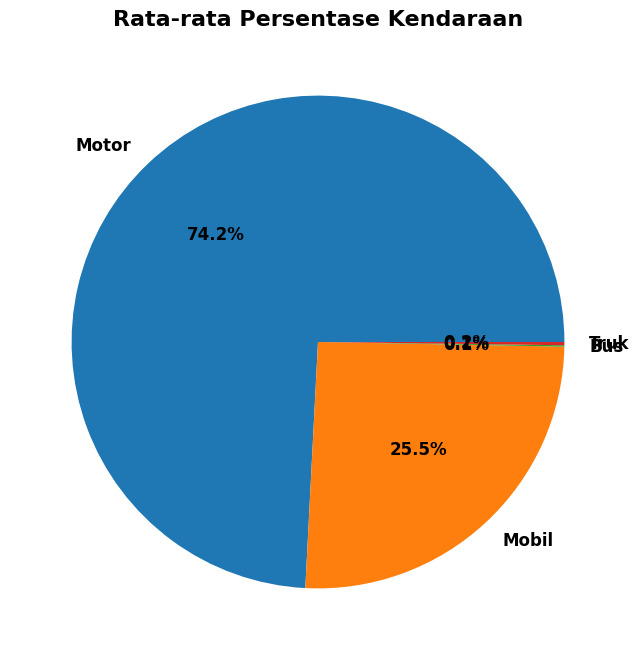

In [ ]:
# PERSENTASE SELURUH JALAN
mean_motor = motor.mean()
mean_mobil = mobil.mean()
mean_bus = bus.mean()
mean_truk = truk.mean()
rata2 = {'Motor': mean_motor, 'Mobil': mean_mobil, 'Bus': mean_bus, 'Truk': mean_truk}
# rata2

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
plt.pie(rata2.values(), labels=rata2.keys(), autopct='%1.1f%%', textprops={'fontsize': 12, 'fontweight': 'bold'})
plt.title('Rata-rata Persentase Kendaraan', fontsize=16, fontweight='bold')
plt.show()

In [ ]:
# DISTRIBUSI TOTAL KENDARAAN
plt.figure(figsize=(10, 6))
df_lhr['Total_Kendaraan'].hist(bins=30, edgecolor='black', alpha=0.7)
plt.axvline(df_lhr['Total_Kendaraan'].mean(), color='red', linestyle='--', label=f'Mean: {df_lhr["Total_Kendaraan"].mean():.0f}')
plt.axvline(df_lhr['Total_Kendaraan'].median(), color='black', linestyle='--', label=f'Median: {df_lhr["Total_Kendaraan"].median():.0f}')
plt.title('Distribusi Total Kendaraan per Jalan')
plt.xlabel('Total Kendaraan')
plt.ylabel('Frekuensi')
plt.legend()

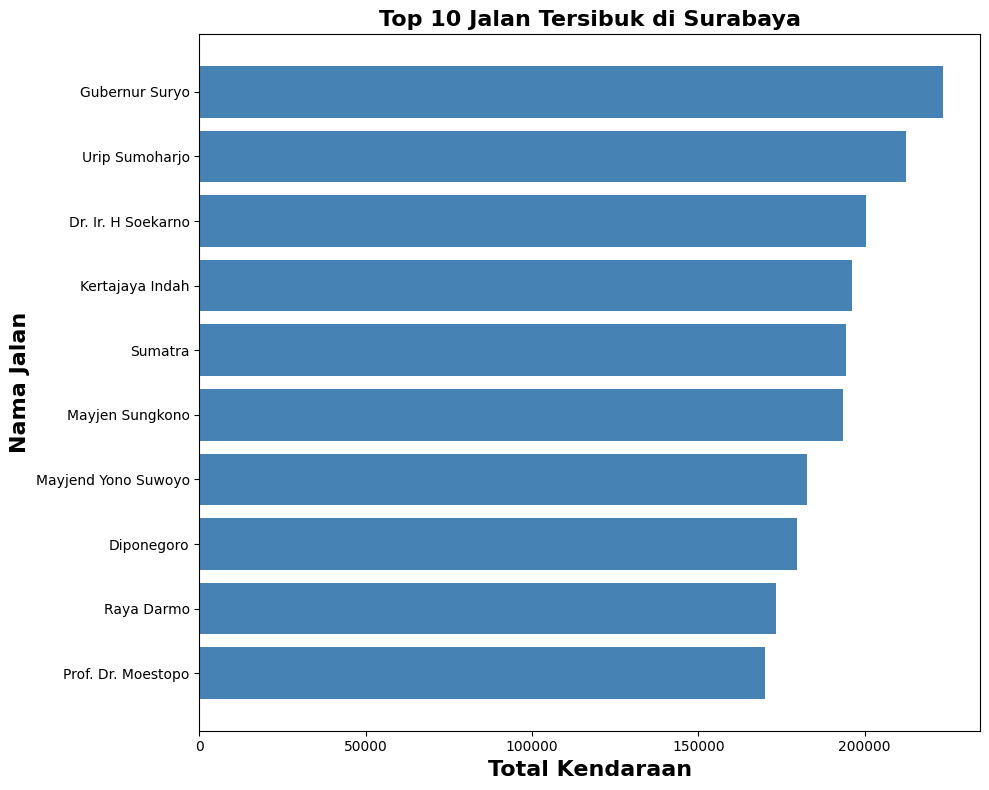

In [ ]:
# 10 JALAN TERSIBUK KE SURABAYA
plt.figure(figsize=(10, 8))
top_10 = df_lhr.nlargest(10, 'Total Kendaraan')
plt.barh(top_10['Nama Jalan'], top_10['Total Kendaraan'], color='steelblue')
plt.title('Top 10 Jalan Tersibuk di Surabaya', fontsize=16, fontweight='bold')
plt.xlabel('Total Kendaraan', fontsize=16, fontweight='bold')
plt.ylabel('Nama Jalan', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

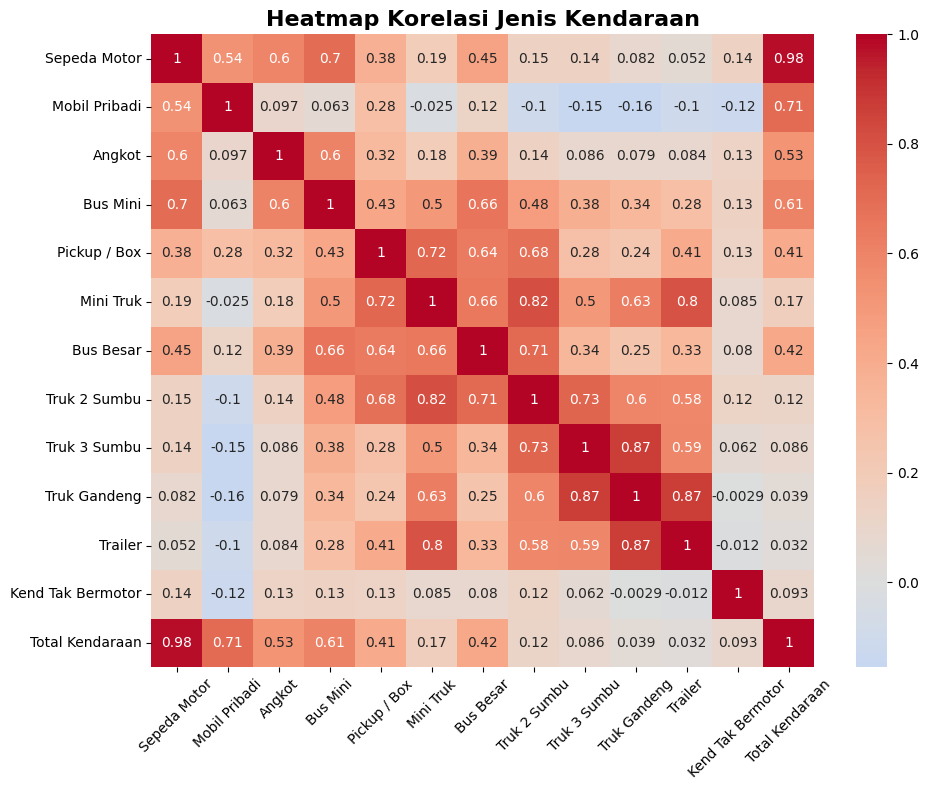

In [ ]:
# kORELASI ANTARA JENIS KENDARAAN
import seaborn as sns
import matplotlib.pyplot as plt
correlation_matrix = df_lhr.select_dtypes(include=['number']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm',center=0)
plt.title('Heatmap Korelasi Jenis Kendaraan',  fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks()
plt.tight_layout()
plt.show()

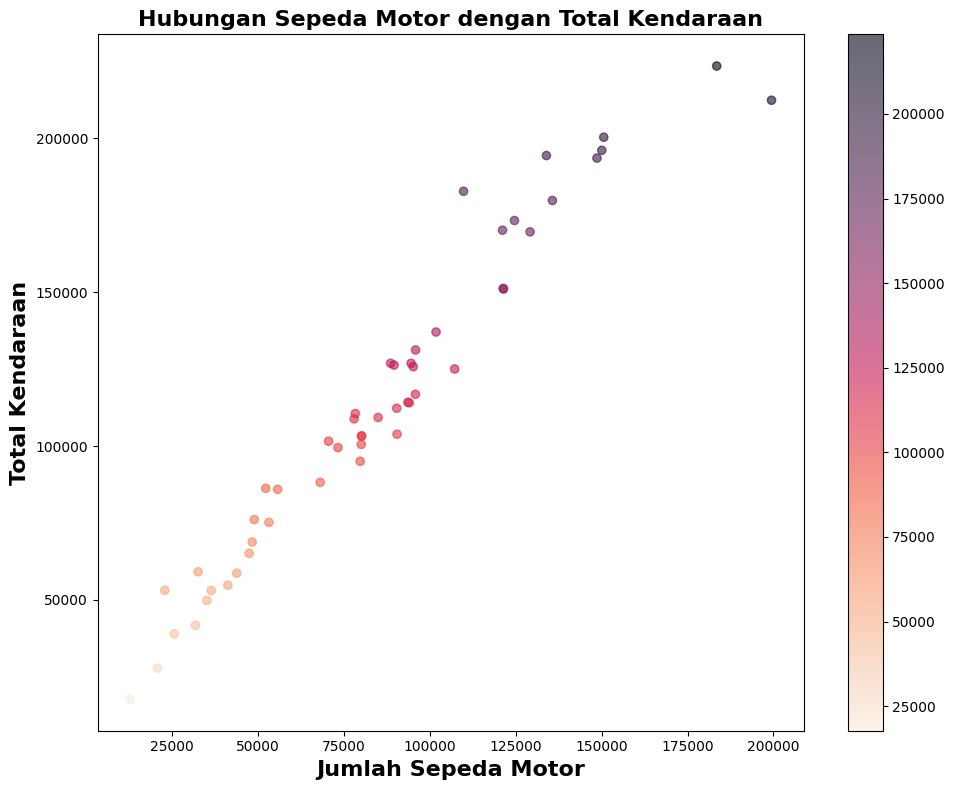

In [ ]:
# KORELASI SEPEDA MOTOR DENGAN TOTAL KENDARAAN
# karena sepeda motor penyumbang terbesar jumlah kendaraan
plt.figure(figsize=(10, 8))
plt.scatter(df_lhr['Sepeda Motor'], df_lhr['Total Kendaraan'], alpha=0.6, c=df_lhr['Total Kendaraan'], cmap='rocket_r')
plt.colorbar()
plt.title('Hubungan Sepeda Motor dengan Total Kendaraan', fontsize=16, fontweight='bold')
plt.xlabel('Jumlah Sepeda Motor', fontsize=16, fontweight='bold')
plt.ylabel('Total Kendaraan', fontsize=16, fontweight='bold')
plt.tight_layout()

In [ ]:
# # TOTAL KENDARAAN
# plt.figure(figsize=(10, 8))
# bins = [df_lhr['Total Kendaraan'].min(),
#         df_lhr['Total Kendaraan'].quantile(0.33),
#         df_lhr['Total Kendaraan'].quantile(0.66),
#         df_lhr['Total Kendaraan'].max()]
# labels = ['Rendah', 'Sedang', 'Tinggi']
# df_lhr['Kategori_Kepadatan'] = pd.cut(df_lhr['Total Kendaraan'], bins=bins, labels=labels, include_lowest=True)
# df_lhr.boxplot(column='Total Kendaraan', by='Kategori_Kepadatan')
# plt.title('Total Kendaraan per Kategori Kepadatan')
# plt.suptitle('')
# plt.xlabel('Kategori Kepadatan')
# plt.ylabel('Total Kendaraan')
# plt.show()

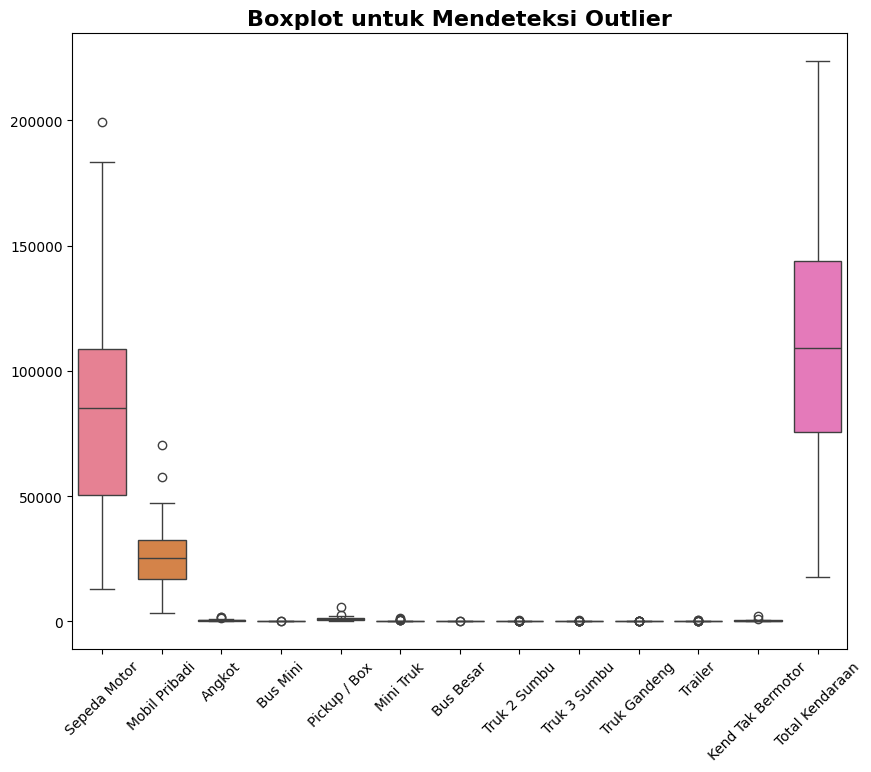

=== BATAS IQR ===
Lower bound:
 Sepeda Motor        -36286.75
Mobil Pribadi        -6561.00
Angkot                -305.75
Bus Mini               -70.25
Pickup / Box          -279.75
Mini Truk             -116.25
Bus Besar              -98.00
Truk 2 Sumbu           -32.75
Truk 3 Sumbu            -4.50
Truk Gandeng             0.00
Trailer                  0.00
Kend Tak Bermotor     -227.25
Total Kendaraan     -26958.25
dtype: float64
Upper bound:
 Sepeda Motor         195451.25
Mobil Pribadi         55667.00
Angkot                 1216.25
Bus Mini                159.75
Pickup / Box           2318.25
Mini Truk               345.75
Bus Besar               182.00
Truk 2 Sumbu             65.25
Truk 3 Sumbu              7.50
Truk Gandeng              0.00
Trailer                   0.00
Kend Tak Bermotor       814.75
Total Kendaraan      246635.75
dtype: float64

=== DATA YANG TERDETEKSI SEBAGAI OUTLIER ===


,Nama Jalan,Sepeda Motor,Mobil Pribadi,Angkot,Bus Mini,Pickup / Box,Mini Truk,Bus Besar,Truk 2 Sumbu,Truk 3 Sumbu,Truk Gandeng,Trailer,Kend Tak Bermotor,Tahun,Total Kendaraan
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2210.0,NaT,NaN
17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.0,NaN,NaN,NaN,NaT,NaN
31,NaN,NaN,NaN,NaN,182.0,NaN,449.0,NaN,98.0,38.0,18.0,18.0,NaN,NaT,NaN
33,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1.0,NaN,NaT,NaN
35,NaN,NaN,NaN,NaN,NaN,5576.0,1286.0,348.0,665.0,168.0,56.0,406.0,NaN,NaT,NaN
37,NaN,NaN,NaN,1719.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
39,NaN,NaN,NaN,1281.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,825.0,NaT,NaN
55,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.0,NaN,NaN,NaN,NaN,NaT,NaN
57,NaN,NaN,NaN,NaN,NaN,NaN,359.0,NaN,NaN,12.0,NaN,NaN,NaN,NaT,NaN


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.boxplot(data=df_lhr.select_dtypes(include='number'))
plt.title("Boxplot untuk Mendeteksi Outlier", fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.show()

# Deteksi outlier menggunakan IQR
Q1 = df_lhr.quantile(0.25, numeric_only=True)
Q3 = df_lhr.quantile(0.75, numeric_only=True)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("=== BATAS IQR ===")
print("Lower bound:\n", lower_bound)
print("Upper bound:\n", upper_bound)

# Menampilkan baris yang terdeteksi sebagai outlier
outliers = df_lhr[(df_lhr.select_dtypes(include='number') < lower_bound) |
              (df_lhr.select_dtypes(include='number') > upper_bound)].dropna(how='all')
print("\n=== DATA YANG TERDETEKSI SEBAGAI OUTLIER ===")
display(outliers)

In [ ]:
# Standardizing
import pandas as pd
from sklearn.preprocessing import StandardScaler
df_std = df_lhr.copy()
num_cols = df_std.select_dtypes(include=['number']).columns
std_scaler = StandardScaler()
df_std[num_cols] = std_scaler.fit_transform(df_std[num_cols])
df_std = pd.DataFrame(df_std)
# df_std

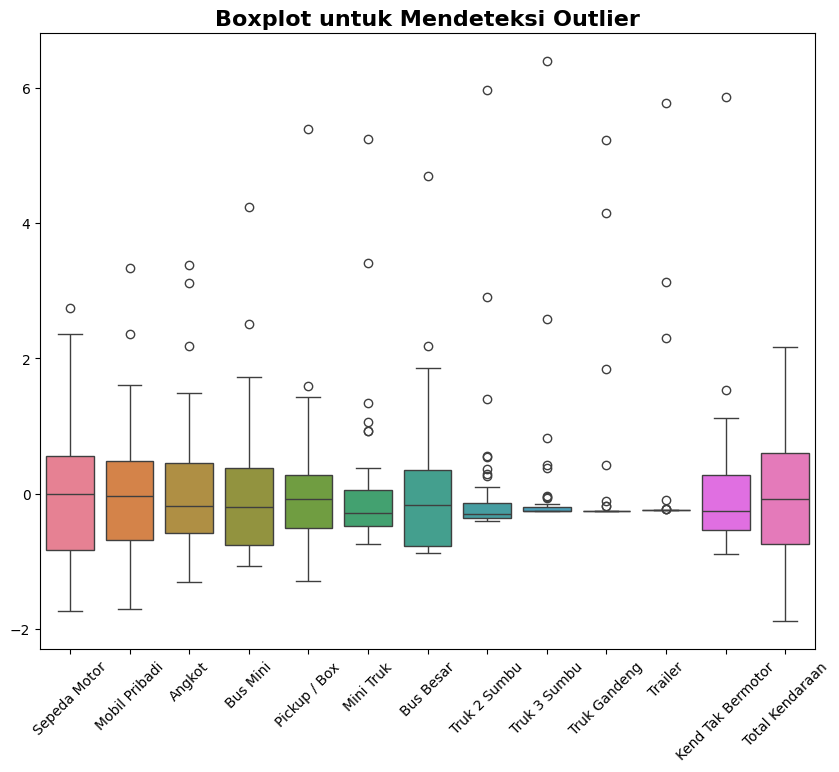

=== BATAS IQR ===
Lower bound:
 Sepeda Motor        -2.919357
Mobil Pribadi       -2.434268
Angkot              -2.140836
Bus Mini            -2.446147
Pickup / Box        -1.684999
Mini Truk           -1.287842
Bus Besar           -2.450146
Truk 2 Sumbu        -0.717551
Truk 3 Sumbu        -0.331025
Truk Gandeng        -0.253788
Trailer             -0.237050
Kend Tak Bermotor   -1.757742
Total Kendaraan     -2.768014
dtype: float64
Upper bound:
 Sepeda Motor         2.645177
Mobil Pribadi        2.222887
Angkot               2.003591
Bus Mini             2.069817
Pickup / Box         1.449945
Mini Truk            0.861062
Bus Besar            2.038959
Truk 2 Sumbu         0.220724
Truk 3 Sumbu        -0.128741
Truk Gandeng        -0.253788
Trailer             -0.237050
Kend Tak Bermotor    1.499939
Total Kendaraan      2.621744
dtype: float64

=== DATA YANG TERDETEKSI SEBAGAI OUTLIER ===


,Nama Jalan,Sepeda Motor,Mobil Pribadi,Angkot,Bus Mini,Pickup / Box,Mini Truk,Bus Besar,Truk 2 Sumbu,Truk 3 Sumbu,Truk Gandeng,Trailer,Kend Tak Bermotor,Tahun,Total Kendaraan
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.862010,NaT,NaN
17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.069742,NaN,NaN,NaN,NaT,NaN
31,NaN,NaN,NaN,NaN,2.506687,NaN,1.341310,NaN,0.534280,0.385397,0.417617,-0.087694,NaN,NaT,NaN
33,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.179188,-0.228753,NaN,NaT,NaN
35,NaN,NaN,NaN,NaN,NaN,5.380994,5.234454,4.700357,5.962870,2.576802,1.835028,3.131767,NaN,NaT,NaN
37,NaN,NaN,NaN,3.372586,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
39,NaN,NaN,NaN,2.179906,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.531984,NaT,NaN
55,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.266201,NaN,NaN,NaN,NaN,NaT,NaN
57,NaN,NaN,NaN,NaN,NaN,NaN,0.922692,NaN,NaN,-0.052885,NaN,NaN,NaN,NaT,NaN


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.boxplot(data=df_std.select_dtypes(include='number'))
plt.title("Boxplot untuk Mendeteksi Outlier", fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.show()

# Deteksi outlier menggunakan IQR
Q1 = df_std.quantile(0.25, numeric_only=True)
Q3 = df_std.quantile(0.75, numeric_only=True)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("=== BATAS IQR ===")
print("Lower bound:\n", lower_bound)
print("Upper bound:\n", upper_bound)

# Menampilkan baris yang terdeteksi sebagai outlier
outliers = df_std[(df_std.select_dtypes(include='number') < lower_bound) |
              (df_std.select_dtypes(include='number') > upper_bound)].dropna(how='all')
print("\n=== DATA YANG TERDETEKSI SEBAGAI OUTLIER ===")
display(outliers)

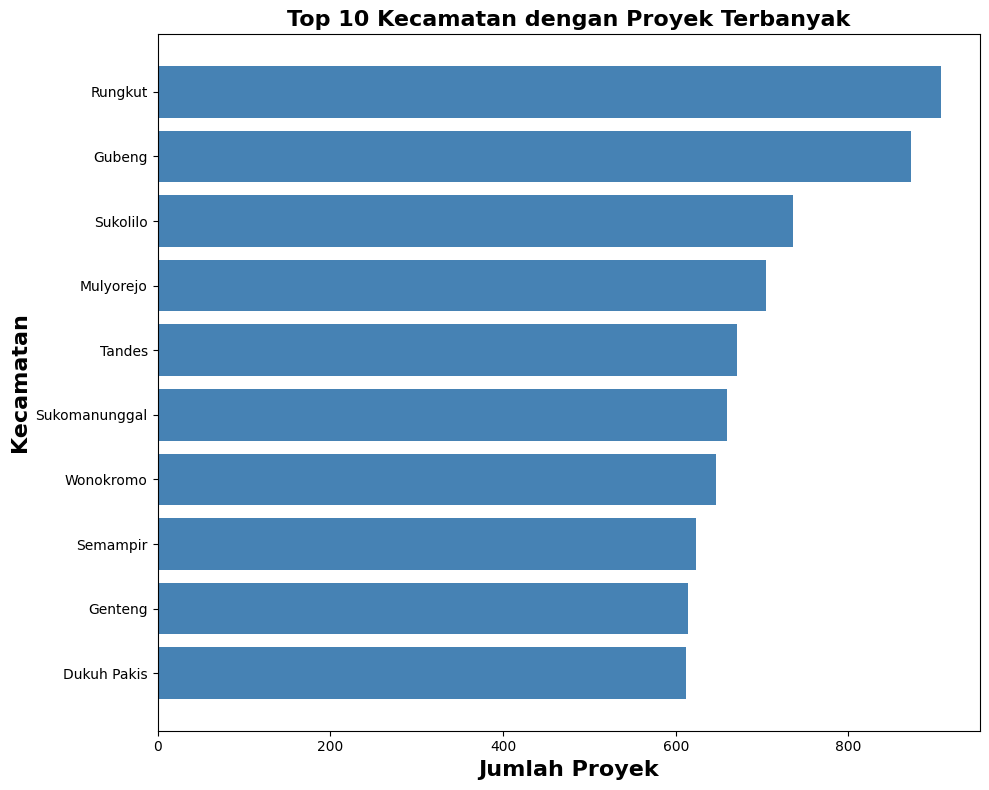

In [ ]:
# KECAMATAN DENGAN PROYEK TERBANYAK
plt.figure(figsize=(10, 8))
top_10_kecamatan = df_pembangunan['Kecamatan'].value_counts().head(10)
plt.barh(top_10_kecamatan.index, top_10_kecamatan.values, color='steelblue')
plt.title('Top 10 Kecamatan dengan Proyek Terbanyak', fontsize=16, fontweight='bold')
plt.xlabel('Jumlah Proyek', fontsize=16, fontweight='bold')
plt.ylabel('Kecamatan', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# GROUPBY BERDASARKAN NAMA JALAN
if 'Nama Jalan' in df_pembangunan.columns:
    jalan_pembangunan = df_pembangunan.groupby('Nama Jalan').agg({
        'Panjang Jalan': ['count', 'sum', 'mean'],
        'Lebar Jalan': 'sum',
        'Luasan Pengerjaan': 'sum',
    }).round(2)

jalan_pembangunan.columns = ['Jumlah Proyek', 'Total Panjang', 'Rata2 Panjang', 'Total Lebar', 'Total Luas']
jalan_pembangunan = jalan_pembangunan.reset_index()
jalan_pembangunan = pd.DataFrame(jalan_pembangunan)
jalan_pembangunan = jalan_pembangunan.sort_values('Jumlah Proyek', ascending=False)

display(jalan_pembangunan.head(10))

,Nama Jalan,Jumlah Proyek,Total Panjang,Rata2 Panjang,Total Lebar,Total Luas
616,Jawar,125,4146.0,33.17,346.20,9894.50
584,Jagir Wonokromo,99,1221.0,12.33,224.35,2452.50
1200,Mayjend Yonosuwoyo,95,1052.5,11.08,219.00,2492.50
1168,Margomulyo,95,3096.0,32.59,254.50,8391.25
1420,Pegirian,80,721.0,9.01,178.00,1640.50
1718,Romokalisari,79,926.5,11.73,187.50,2168.00
894,Kembang Jepun,70,756.5,10.81,219.00,2722.25
1634,Raya Lontar,70,596.0,8.51,133.50,1147.50
1,A Yani,68,891.6,13.11,220.80,3030.39
933,Kertajaya Indah,68,1353.9,19.91,144.35,1967.57


In [ ]:
jalan_pembangunan.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2181 entries, 616 to 29
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Nama Jalan     2181 non-null   object 
 1   Jumlah Proyek  2181 non-null   int64  
 2   Total Panjang  2181 non-null   float64
 3   Rata2 Panjang  2181 non-null   float64
 4   Total Lebar    2181 non-null   float64
 5   Total Luas     2181 non-null   float64
dtypes: float64(4), int64(1), object(1)
memory usage: 119.3+ KB


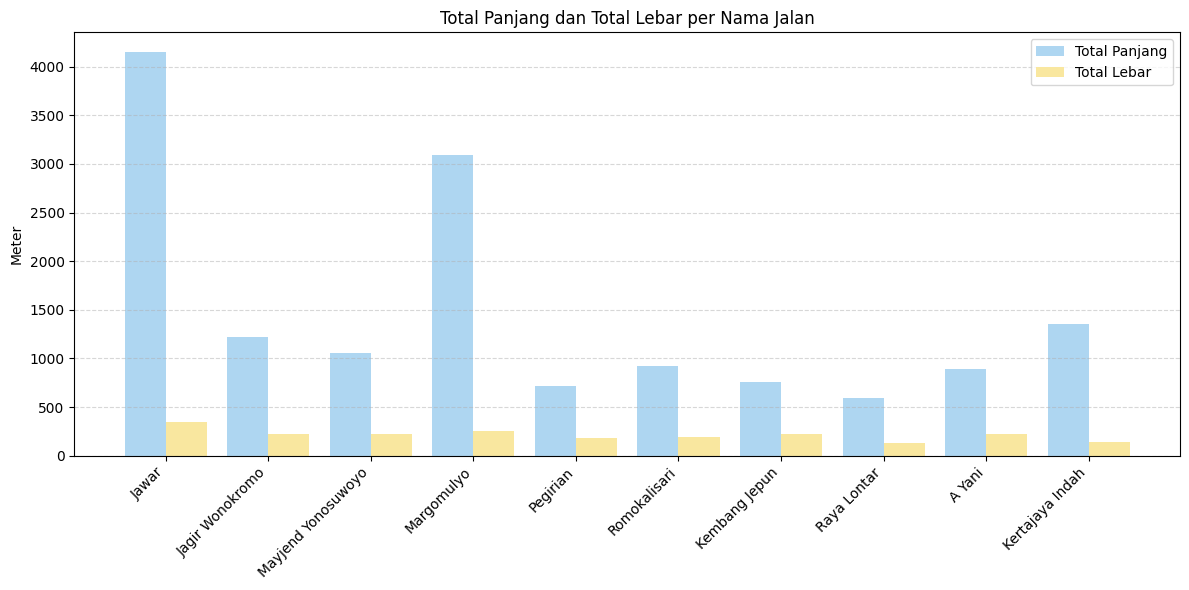

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

top10 = jalan_pembangunan.head(10)
x = np.arange(len(top10))
width = 0.4
plt.figure(figsize=(12, 6))
plt.bar(x - width/2, top10["Total Panjang"], width, label="Total Panjang", color="#AED6F1")
plt.bar(x + width/2, top10["Total Lebar"], width, label="Total Lebar", color="#F9E79F")

plt.xticks(x, top10['Nama Jalan'], rotation=45, ha='right')
plt.ylabel("Meter")
plt.title("Total Panjang dan Total Lebar per Nama Jalan")
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [ ]:
proyek = jalan_pembangunan['Jumlah Proyek'].sum()
proyek

np.int64(14375)

In [ ]:
# JALAN YANG SERING ADA PERBAIKAN
if 'Nama Jalan' in df_pembangunan.columns:
    sering = df_pembangunan['Nama Jalan'].value_counts().head(10)
sering

,count
Nama Jalan,
Jawar,125
Jagir Wonokromo,99
Mayjend Yonosuwoyo,95
Margomulyo,95
Pegirian,80
Romokalisari,79
Raya Lontar,70
Kembang Jepun,70
Kertajaya Indah,68


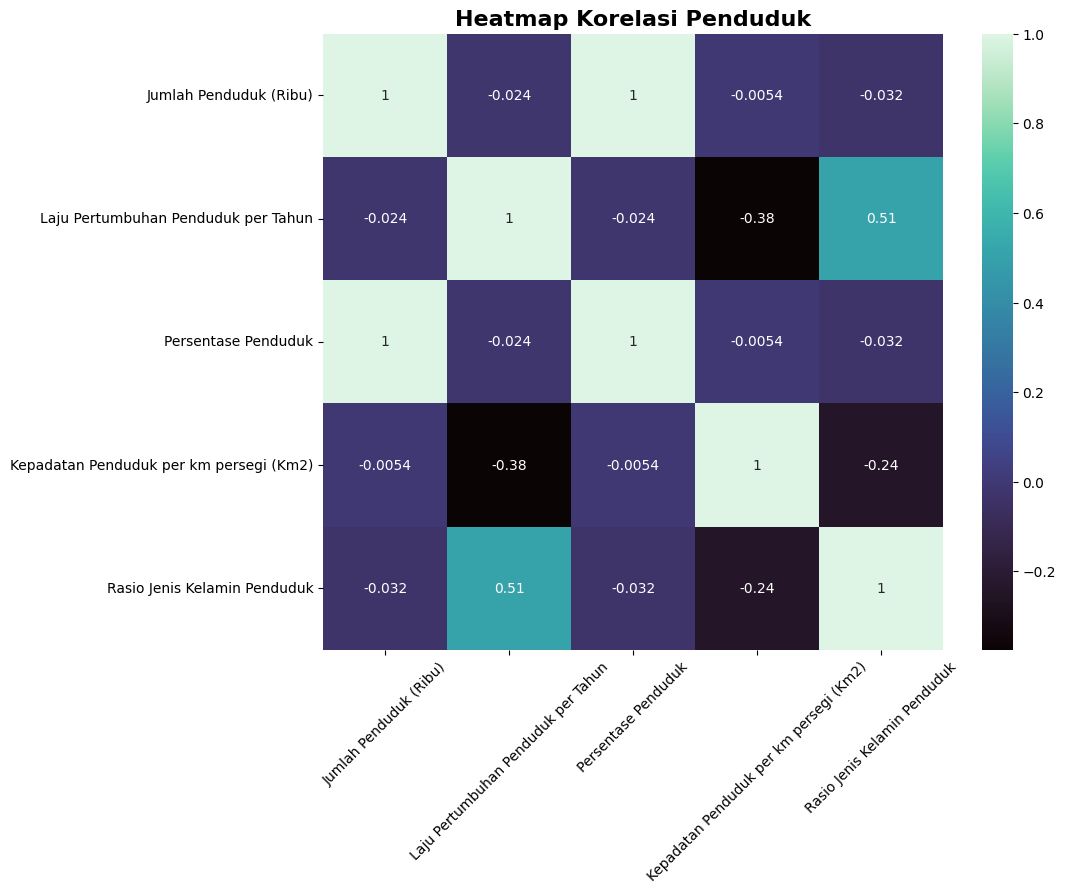

In [ ]:
# KORELASI ANTAR FITUR
plt.figure(figsize=(10,8))
sns.heatmap(df_penduduk.select_dtypes(include=['number']).corr(), annot=True, cmap='mako')
plt.title('Heatmap Korelasi Penduduk', fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# # DISTRIBUSI JUMLAH PENDUDUK
# plt.figure(figsize=(8,5))
# sns.histplot(df_penduduk['Jumlah Penduduk (Ribu)'], bins=10, kde=True)
# plt.title('Distribusi Jumlah Penduduk')
# plt.xlabel('Jumlah Penduduk')
# plt.show()

In [ ]:
# # LAJU PERTUMBUHAN PENDUDUK DIBANDINGKAN JUMLAH PENDUDUK
# plt.figure(figsize=(12,7)) # Increased figure size for better readability
# sns.barplot(x='Kecamatan', y='Laju Pertumbuhan Penduduk per Tahun', data=df_penduduk, color='skyblue', label='Laju Pertumbuhan')
# sns.barplot(x='Kecamatan', y='Jumlah Penduduk (Ribu)', data=df_penduduk, color='lightcoral', label='Jumlah Penduduk')
# plt.title('Laju Pertumbuhan vs Jumlah Penduduk per Kecamatan', fontsize=14, pad=20)
# plt.xlabel('Kecamatan', fontsize=12)
# plt.ylabel('Nilai', fontsize=12) # Renamed ylabel to 'Nilai' since it represents both growth and count
# plt.xticks(rotation=90) # Rotate x-axis labels for better readability
# plt.legend()
# plt.tight_layout()
# plt.show()

# MARGING DATASET

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_merge1 = pd.merge(df_lhr, jalan_pembangunan, on='Nama Jalan', how='left')

print(f"Shape df_lhr          : {df_lhr.shape}")
print(f"Shape df_pembangunan  : {jalan_pembangunan.shape}")
print(f"Shape setelah merging : {df_merge1.shape}")


# df_merge1 = df_merge1.dropna(inplace=True)
df_merge1 = pd.DataFrame(df_merge1)
# df_merge1

Shape df_lhr          : (51, 15)
Shape df_pembangunan  : (2181, 6)
Shape setelah merging : (51, 20)


In [ ]:
print(df_merge1.columns)

Index(['Nama Jalan', 'Sepeda Motor', 'Mobil Pribadi', 'Angkot', 'Bus Mini',
       'Pickup / Box', 'Mini Truk', 'Bus Besar', 'Truk 2 Sumbu',
       'Truk 3 Sumbu', 'Truk Gandeng', 'Trailer', 'Kend Tak Bermotor', 'Tahun',
       'Total Kendaraan', 'Jumlah Proyek', 'Total Panjang', 'Rata2 Panjang',
       'Total Lebar', 'Total Luas'],
      dtype='object')


In [ ]:
nama_jalan_kecamatan = df_pembangunan[['Nama Jalan', 'Kecamatan']].drop_duplicates(subset=['Nama Jalan']).set_index('Nama Jalan')
df_merge1 = df_merge1.merge(nama_jalan_kecamatan, on='Nama Jalan', how='left')

df_merge = pd.merge(df_merge1, df_penduduk, on='Kecamatan', how='left')
print(f"Shape df_merge1       : {df_merge1.shape}")
print(f"Shape df_penduduk     : {df_penduduk.shape}")
print(f"Shape setelah merging : {df_merge.shape}")
df_merge = pd.DataFrame(df_merge)
df_merge

Shape df_merge1       : (51, 21)
Shape df_penduduk     : (32, 6)
Shape setelah merging : (51, 26)


,Nama Jalan,Sepeda Motor,Mobil Pribadi,Angkot,Bus Mini,Pickup / Box,Mini Truk,Bus Besar,Truk 2 Sumbu,Truk 3 Sumbu,...,Total Panjang,Rata2 Panjang,Total Lebar,Total Luas,Kecamatan,Jumlah Penduduk (Ribu),Laju Pertumbuhan Penduduk per Tahun,Persentase Penduduk,Kepadatan Penduduk per km persegi (Km2),Rasio Jenis Kelamin Penduduk
0,Adityawarman,94572,30049,421,49,1094,215,40,52,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Basuki Rahmat,121455,25879,501,66,765,58,83,5,0,...,227.80,9.90,37.50,274.90,Genteng,63.2,1.97,2.00,15593.0,96.8
2,Blauran,70576,29627,268,44,798,49,26,10,0,...,62.00,6.20,20.50,127.00,Sawahan,216.4,1.23,6.85,31226.0,98.2
3,Bubutan,55753,27405,334,0,2045,100,77,29,0,...,198.00,7.62,55.00,422.00,Bubutan,107.8,1.34,3.41,27933.0,98.9
4,Dharmawangsa,73289,24347,482,26,779,98,61,0,0,...,404.00,7.48,103.80,694.44,Gubeng,143.9,1.47,4.55,18004.0,96.3
5,Dinoyo,79762,13304,613,33,789,86,24,6,4,...,121.00,13.44,19.50,271.00,Keputran,NaN,NaN,NaN,NaN,NaN
6,Diponegoro,135693,40628,1028,84,1655,122,56,43,0,...,27.20,3.89,10.00,36.60,Tegalsari,108.1,1.34,3.42,25193.0,97.7
7,Dr. Soetomo,89619,35370,341,11,772,56,0,2,1,...,213.00,7.10,61.00,433.00,Tegalsari,108.1,1.34,3.42,25193.0,97.7
8,Embong Malang,90379,21006,414,40,169,39,78,0,11,...,586.70,14.67,108.00,1388.60,Tegalsari,108.1,1.34,3.42,25193.0,97.7
9,Gemblongan,35166,13738,218,15,517,24,44,24,0,...,59.60,14.90,24.00,179.80,Bubutan,107.8,1.34,3.41,27933.0,98.9


In [ ]:
df_merge.isna().sum()

,0
Nama Jalan,0
Sepeda Motor,0
Mobil Pribadi,0
Angkot,0
Bus Mini,0
Pickup / Box,0
Mini Truk,0
Bus Besar,0
Truk 2 Sumbu,0
Truk 3 Sumbu,0


In [ ]:
# MENGHAPUS NULL VALUE
df_merge = df_merge.dropna(subset=['Jumlah Proyek', 'Total Panjang',	'Rata2 Panjang',	'Total Lebar',	'Total Luas',	'Kecamatan',	'Jumlah Penduduk (Ribu)',	'Laju Pertumbuhan Penduduk per Tahun', 'Persentase Penduduk',	'Kepadatan Penduduk per km persegi (Km2)',	'Rasio Jenis Kelamin Penduduk']).reset_index(drop=True)
df_merge = pd.DataFrame(df_merge)
df_merge

,Nama Jalan,Sepeda Motor,Mobil Pribadi,Angkot,Bus Mini,Pickup / Box,Mini Truk,Bus Besar,Truk 2 Sumbu,Truk 3 Sumbu,...,Total Panjang,Rata2 Panjang,Total Lebar,Total Luas,Kecamatan,Jumlah Penduduk (Ribu),Laju Pertumbuhan Penduduk per Tahun,Persentase Penduduk,Kepadatan Penduduk per km persegi (Km2),Rasio Jenis Kelamin Penduduk
0,Basuki Rahmat,121455,25879,501,66,765,58,83,5,0,...,227.80,9.90,37.50,274.90,Genteng,63.2,1.97,2.00,15593.0,96.8
1,Blauran,70576,29627,268,44,798,49,26,10,0,...,62.00,6.20,20.50,127.00,Sawahan,216.4,1.23,6.85,31226.0,98.2
2,Bubutan,55753,27405,334,0,2045,100,77,29,0,...,198.00,7.62,55.00,422.00,Bubutan,107.8,1.34,3.41,27933.0,98.9
3,Dharmawangsa,73289,24347,482,26,779,98,61,0,0,...,404.00,7.48,103.80,694.44,Gubeng,143.9,1.47,4.55,18004.0,96.3
4,Diponegoro,135693,40628,1028,84,1655,122,56,43,0,...,27.20,3.89,10.00,36.60,Tegalsari,108.1,1.34,3.42,25193.0,97.7
5,Dr. Soetomo,89619,35370,341,11,772,56,0,2,1,...,213.00,7.10,61.00,433.00,Tegalsari,108.1,1.34,3.42,25193.0,97.7
6,Embong Malang,90379,21006,414,40,169,39,78,0,11,...,586.70,14.67,108.00,1388.60,Tegalsari,108.1,1.34,3.42,25193.0,97.7
7,Gemblongan,35166,13738,218,15,517,24,44,24,0,...,59.60,14.90,24.00,179.80,Bubutan,107.8,1.34,3.41,27933.0,98.9
8,Genteng Kali,78004,28853,269,5,1462,29,1,4,0,...,3032.00,104.55,103.45,13584.45,Genteng,63.2,1.97,2.00,15593.0,96.8
9,Gubeng Pojok,93636,19603,272,40,459,45,35,12,0,...,222.50,15.89,38.00,566.50,Gubeng,143.9,1.47,4.55,18004.0,96.3


In [ ]:
df_merge.to_csv('final_merge_data.csv', index=False)

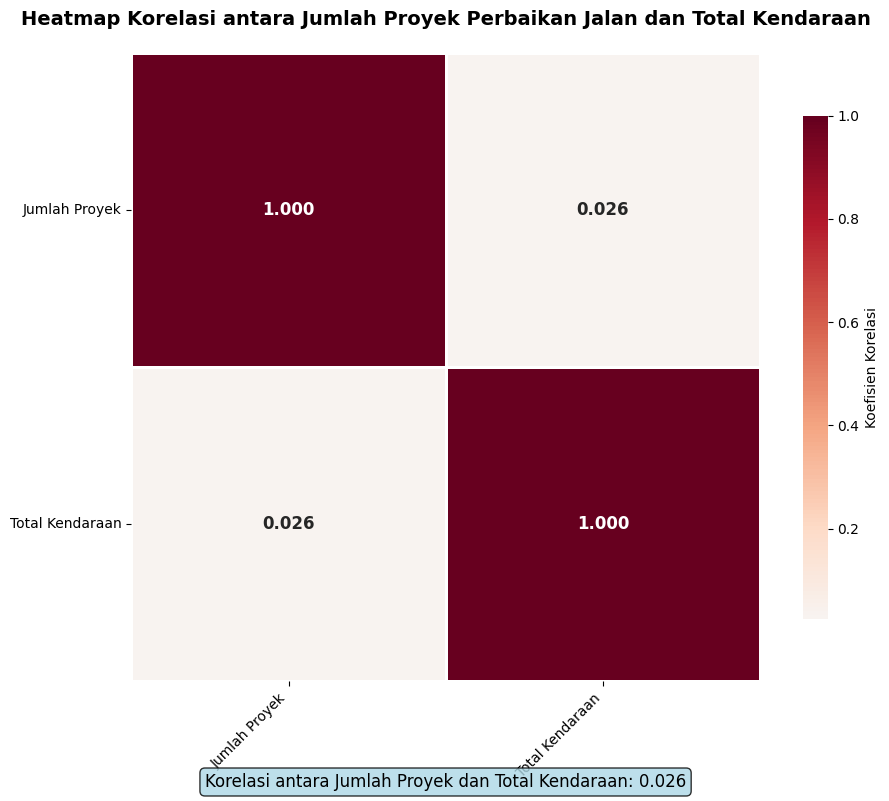

In [ ]:
# KORELASI LALU LINTAS DAN PERBAIKAN JALAN - DETAILED HEATMAP
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Hitung matriks korelasi
corr_matrix = df_merge[['Jumlah Proyek', 'Total Kendaraan']].corr()

# Buat heatmap dengan styling yang lebih baik
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mask untuk segitiga atas

heatmap = sns.heatmap(corr_matrix,
                      annot=True,
                      cmap='RdBu_r',
                      center=0,
                      square=True,
                      fmt='.3f',
                      cbar_kws={'shrink': 0.8, 'label': 'Koefisien Korelasi'},
                      linewidths=1,
                      linecolor='white',
                      annot_kws={'size': 12, 'weight': 'bold'})

# Customize plot
plt.title('Heatmap Korelasi antara Jumlah Proyek Perbaikan Jalan dan Total Kendaraan',
          fontsize=14, pad=20, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Tambahkan informasi korelasi sebagai text
corr_value = corr_matrix.iloc[0,1]
plt.figtext(0.5, 0.01,
           f'Korelasi antara Jumlah Proyek dan Total Kendaraan: {corr_value:.3f}',
           ha='center', fontsize=12,
           bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.show()

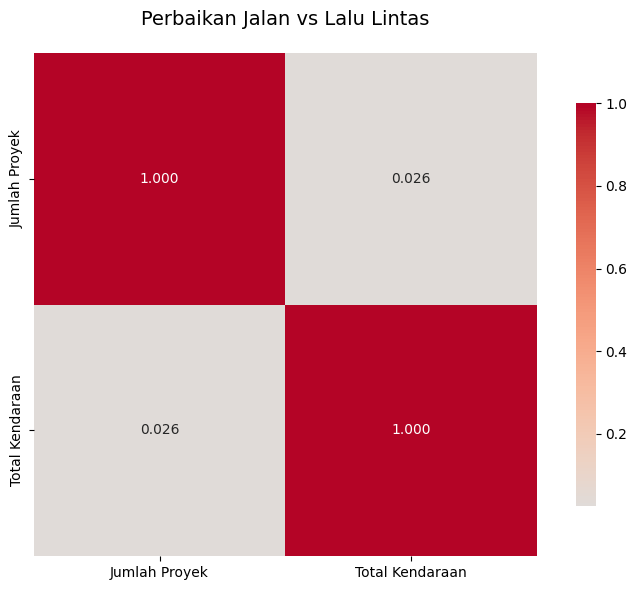

In [ ]:
# KORELASI LALU LINTAS DAN PERBAIKAN JALAN - HEATMAP VERSION
import seaborn as sns
import matplotlib.pyplot as plt

# Hitung matriks korelasi
corr_matrix = df_merge[['Jumlah Proyek', 'Total Kendaraan']].corr()

# Buat heatmap
plt.figure(figsize=(8, 6))
heatmap = sns.heatmap(corr_matrix,
                      annot=True,
                      cmap='coolwarm',
                      center=0,
                      square=True,
                      fmt='.3f',
                      cbar_kws={'shrink': 0.8})

plt.title('Perbaikan Jalan vs Lalu Lintas', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

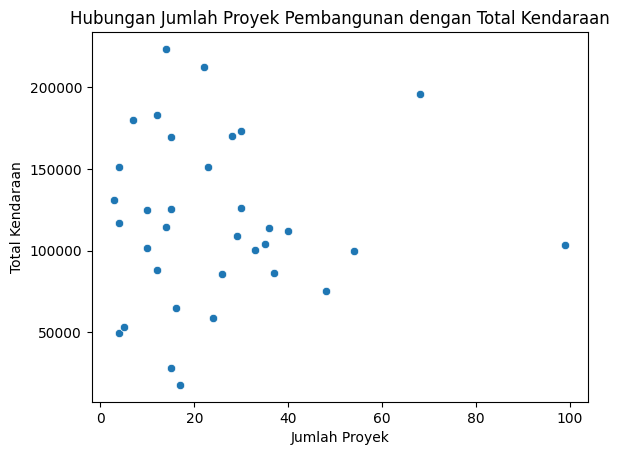

In [ ]:
# hubungan antara total kendaraan dengan jumlah proyek
sns.scatterplot(x='Jumlah Proyek', y='Total Kendaraan', data=df_merge)
plt.title('Hubungan Jumlah Proyek Pembangunan dengan Total Kendaraan')
plt.show()

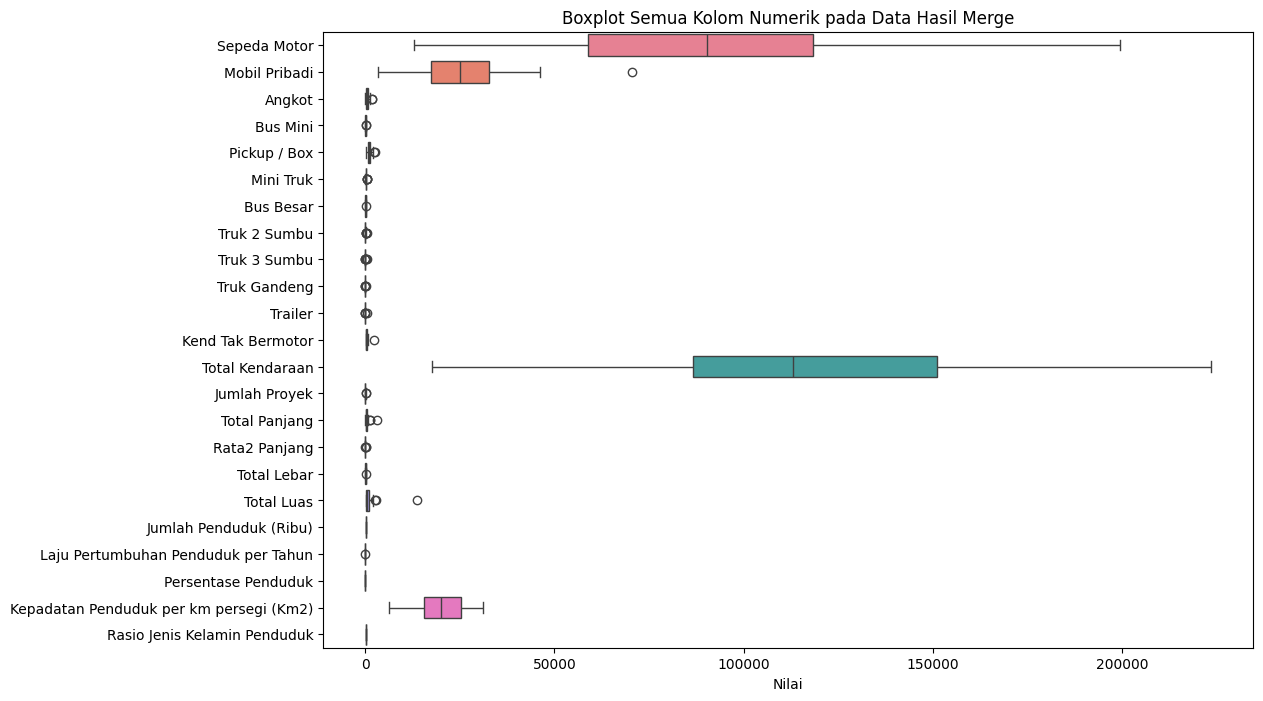

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_boxplot_all_numeric(df):
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    plt.figure(figsize=(12, 8))
    sns.boxplot(data=df[numeric_cols], orient='h')
    plt.title('Boxplot Semua Kolom Numerik pada Data Hasil Merge')
    plt.xlabel('Nilai')
    plt.show()
plot_boxplot_all_numeric(df_merge)

 Menghitung intensitas lalu lintas diperoleh dari dari pembagian total volume kendaraan pada suatu ruas jalan dengan total lebar jalan tersebut, sehingga menggambarkan kepadatan kendaraan per satuan lebar jalan.

In [ ]:
import numpy as np

# Handle potential division by zero in 'Total Lebar'
df_merge['Total Lebar Safe'] = df_merge['Total Lebar'].replace(0, np.nan)

# Create 'Traffic Intensity' column
df_merge['intensitas lalu lintas'] = df_merge['Total Kendaraan'] / df_merge['Total Lebar Safe']

# Drop the temporary 'Total Lebar Safe' column
df_merge.drop(columns=['Total Lebar Safe'], inplace=True)

print(df_merge[['Nama Jalan', 'Total Kendaraan', 'Total Lebar', 'intensitas lalu lintas']].head())
print(df_merge.info())

      Nama Jalan  Total Kendaraan  Total Lebar  intensitas lalu lintas
0  Basuki Rahmat           151022         37.5             4027.253333
1        Blauran           101569         20.5             4954.585366
2        Bubutan            85919         55.0             1562.163636
3   Dharmawangsa            99500        103.8              958.574181
4     Diponegoro           179822         10.0            17982.200000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 27 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Nama Jalan                               34 non-null     object        
 1   Sepeda Motor                             34 non-null     int64         
 2   Mobil Pribadi                            34 non-null     int64         
 3   Angkot                                   34 non-null     int64         
 4   Bus 

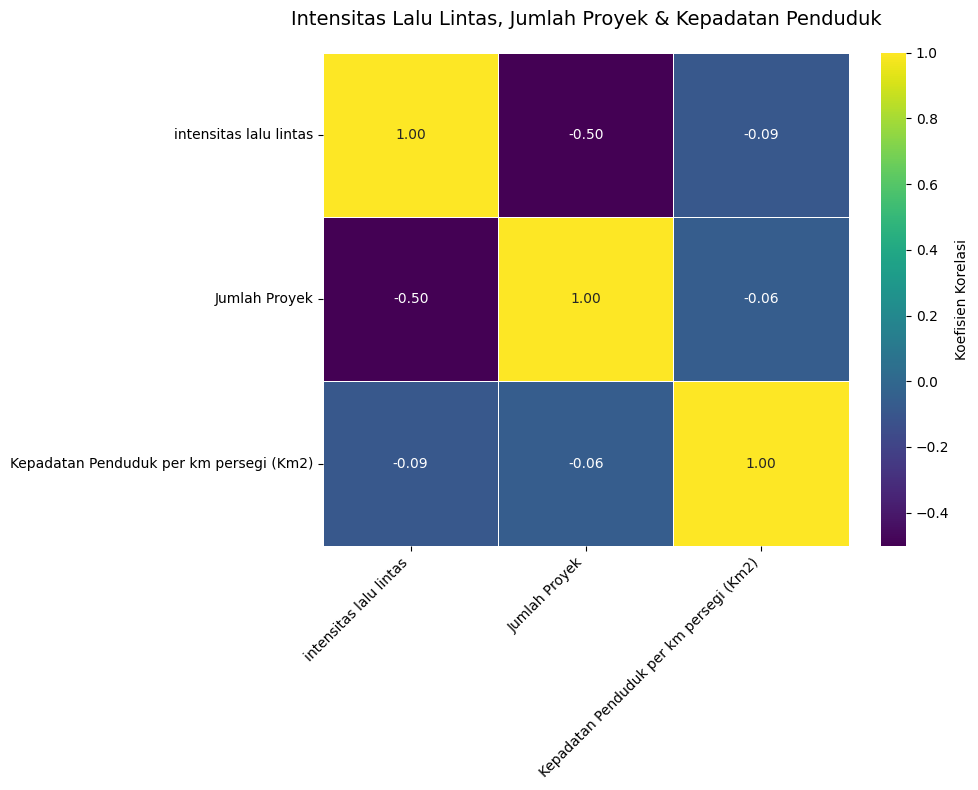

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for the specified columns
correlation_features = df_merge[['intensitas lalu lintas', 'Jumlah Proyek', 'Kepadatan Penduduk per km persegi (Km2)']].corr()

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_features,
            annot=True,
            cmap='viridis',
            fmt='.2f',
            linewidths=.5,
            cbar_kws={'label': 'Koefisien Korelasi'})
plt.title('Intensitas Lalu Lintas, Jumlah Proyek & Kepadatan Penduduk', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
df_merge[['Total Kendaraan', 'Jumlah Proyek', 'Total Panjang', 'Rata2 Panjang', 'Total Lebar', 'Total Luas', 'Kecamatan', 'Jumlah Penduduk (Ribu)', 'Kepadatan Penduduk per km persegi (Km2)', 'intensitas lalu lintas']].describe()

,Total Kendaraan,Jumlah Proyek,Total Panjang,Rata2 Panjang,Total Lebar,Total Luas,Jumlah Penduduk (Ribu),Kepadatan Penduduk per km persegi (Km2),intensitas lalu lintas
count,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000
mean,117681.235294,24.676471,372.086176,14.222353,56.837059,1047.987941,123.276471,19974.911765,3990.947944
std,50681.630006,20.182081,562.938534,17.428069,46.522235,2323.217928,47.510714,6619.355674,4398.322150
min,17746.000000,3.000000,16.000000,3.890000,7.000000,36.000000,62.800000,6316.000000,449.265823
25%,86734.750000,12.000000,105.100000,6.815000,24.000000,180.320000,95.425000,15593.000000,1072.437369
50%,113164.000000,19.500000,191.500000,9.510000,37.750000,423.800000,108.100000,20069.000000,2421.185467
75%,151186.250000,32.250000,449.850000,14.827500,87.337500,1038.425000,163.475000,25193.000000,5164.988934
max,223533.000000,99.000000,3032.000000,104.550000,224.350000,13584.450000,239.300000,31226.000000,18746.714286


In [ ]:
import matplotlib.pyplot as plt

# Sort by 'Traffic Intensity' in descending order and select the top 10
# top_intensity_roads = df_merge.sort_values(by='Traffic Intensity', ascending=False).head(10)

# # Create the bar chart
# plt.figure(figsize=(12, 7))
# sns.barplot(x='Traffic Intensity', y='Nama Jalan', data=top_intensity_roads, palette='Reds_d')

# plt.xlabel('Traffic Intensity', fontsize=12)
# plt.ylabel('Nama Jalan', fontsize=12)
# plt.title('Top 10 Jalan dengan Intensitas Lalu Lintas Tertinggi', fontsize=14, pad=20)
# plt.grid(axis='x', linestyle='--', alpha=0.7)
# plt.tight_layout()
# plt.show()